<a href="https://colab.research.google.com/github/Imaad18/Generative-AI/blob/main/Generative_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

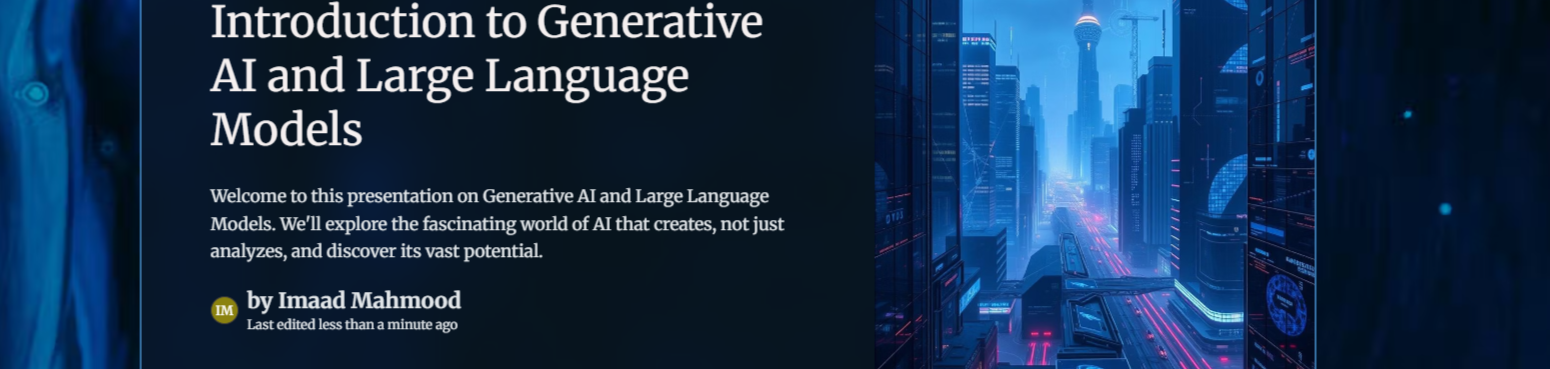

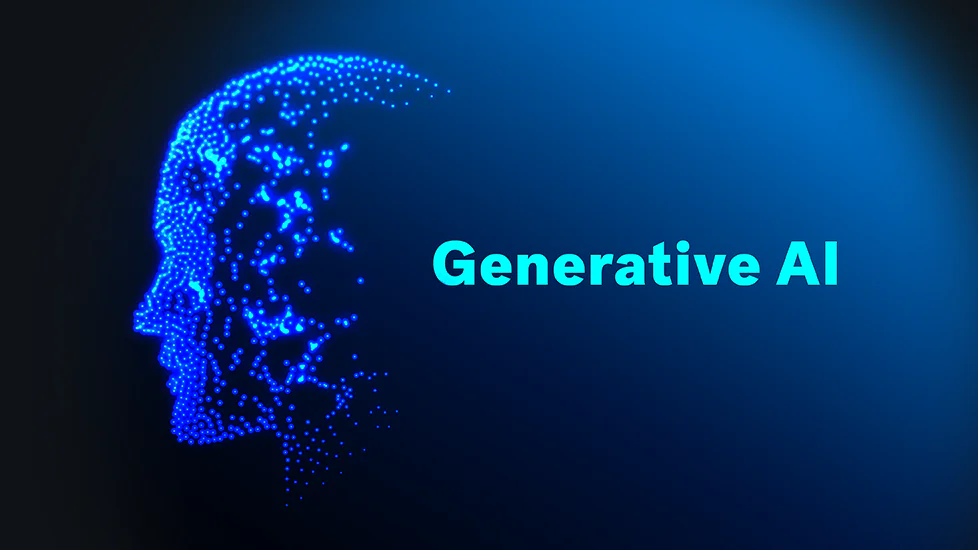







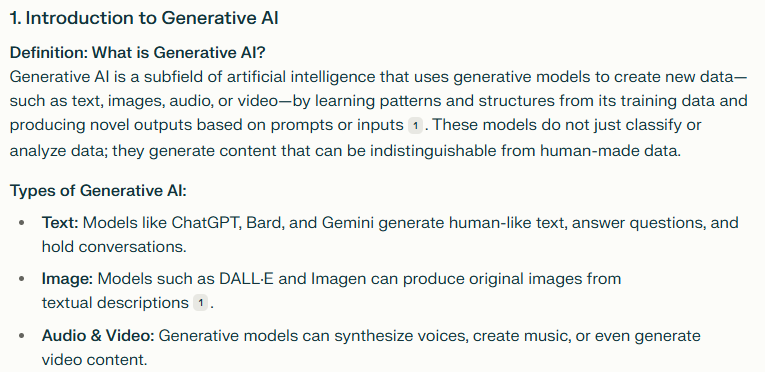

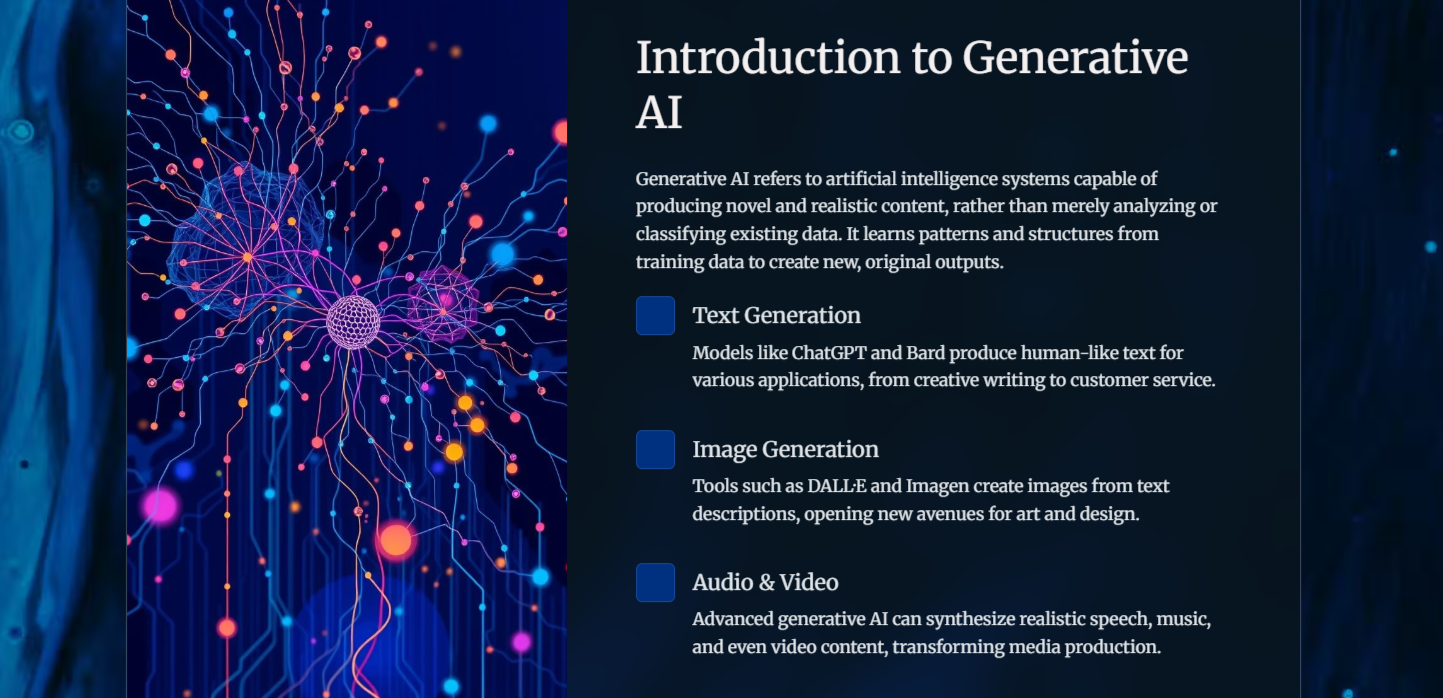

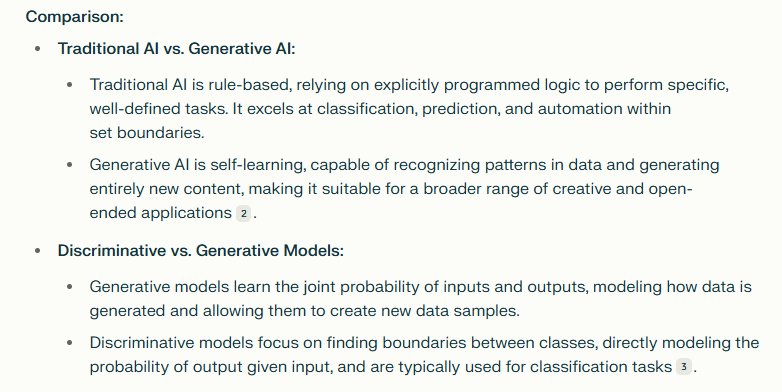

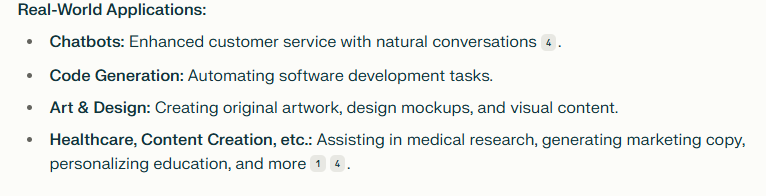

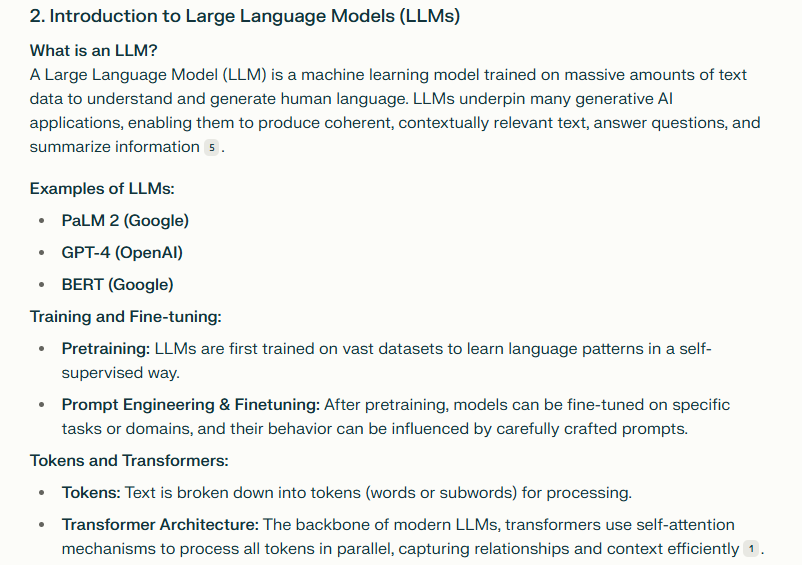

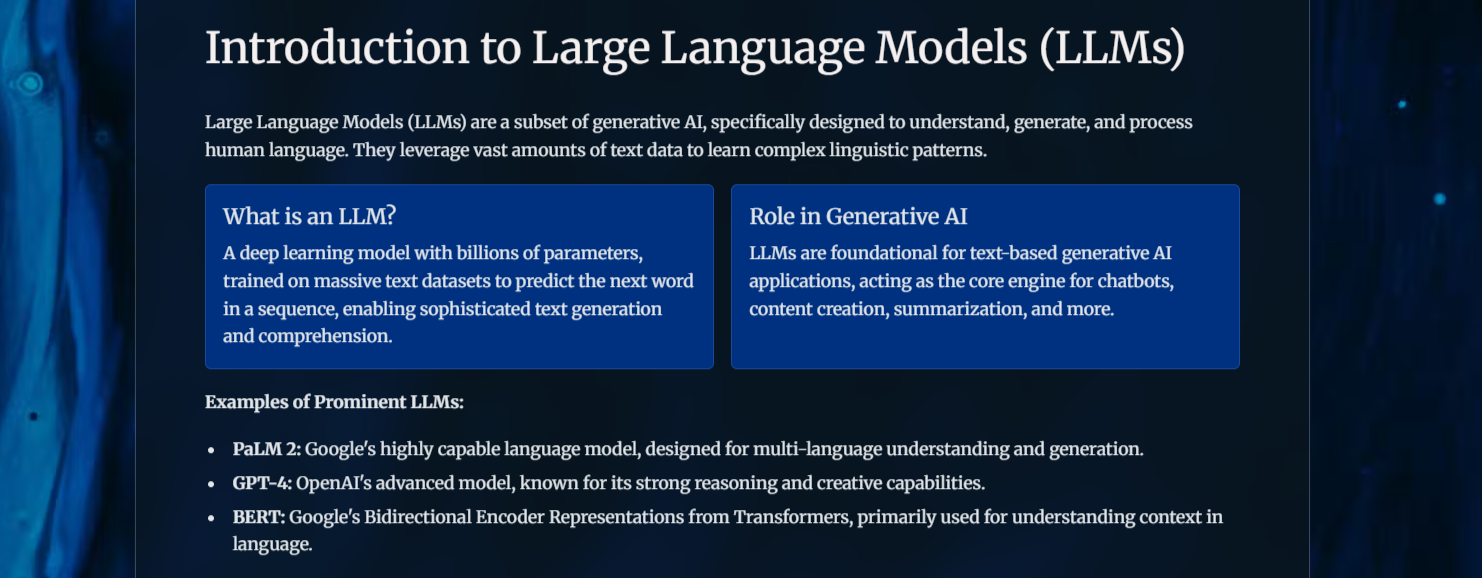

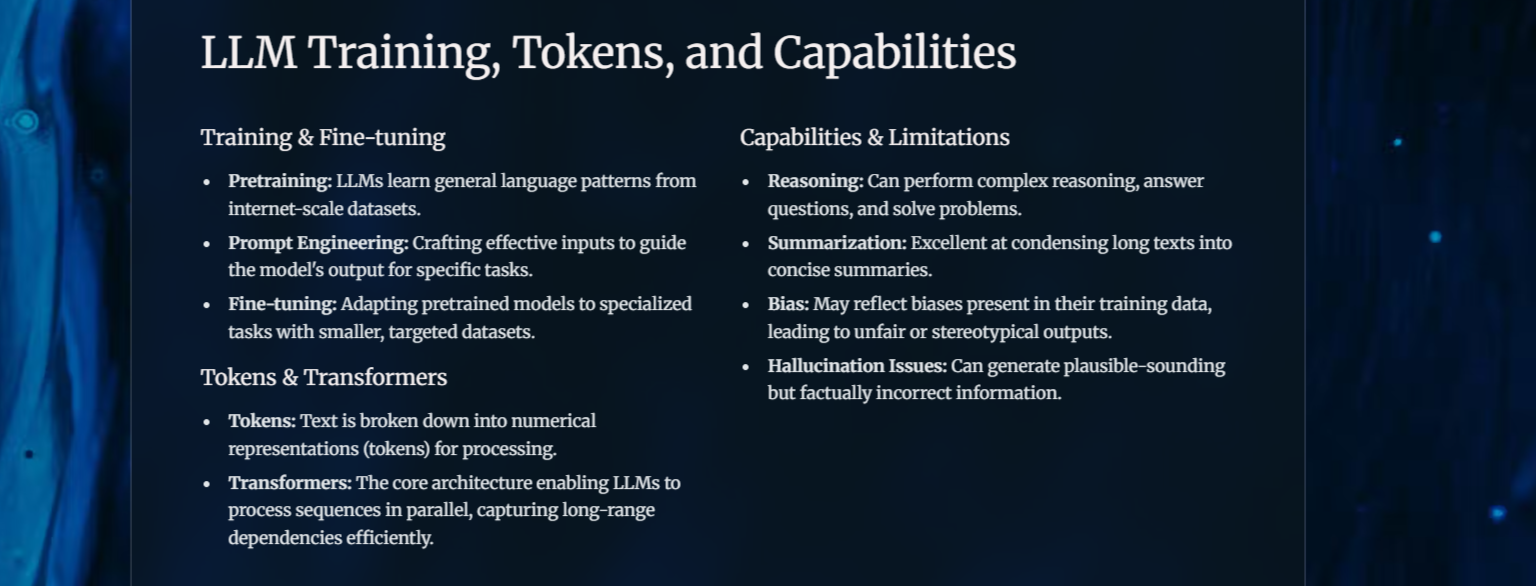

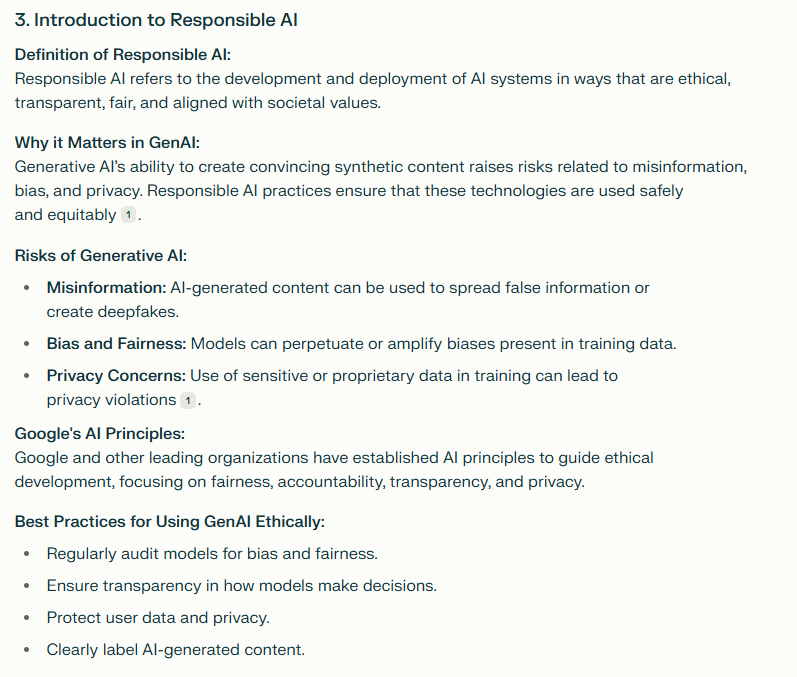

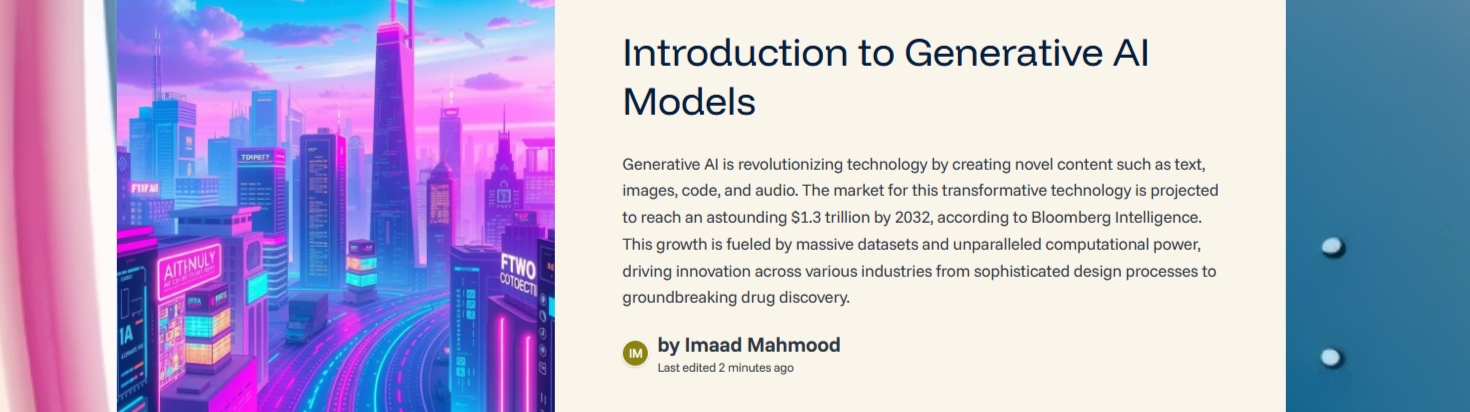

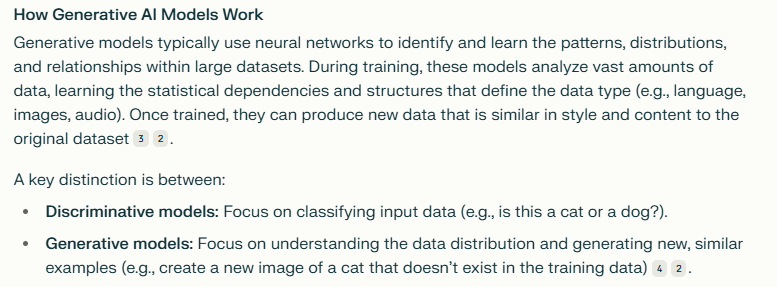

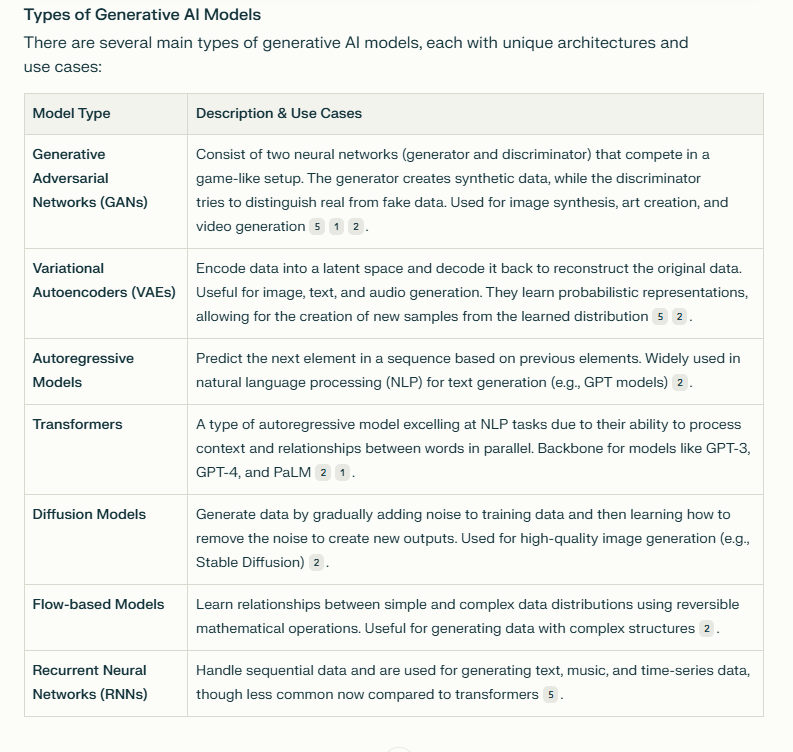

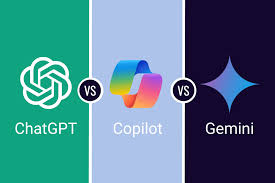

---
# Hands-On: Working with Generative AI APIs

> In this section, you'll go from theory to practice. We'll use the **Google Generative AI SDK** (Gemini) to run real examples of the concepts covered above.
>
> **Prerequisites:** A free API key from [Google AI Studio](https://aistudio.google.com)

## Step 1: Install Dependencies

Install the Google Generative AI SDK:

In [ ]:
# Install the Google Generative AI SDK
!pip install -q google-generativeai

## Step 2: Configure Your API Key

Get a free API key at [aistudio.google.com](https://aistudio.google.com), then paste it below.

> **Security tip:** Never hard-code API keys in shared notebooks. Use `userdata` in Colab or environment variables locally.

In [ ]:
import google.generativeai as genai

# --- Colab: use Colab secrets (recommended) ---
# from google.colab import userdata
# GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# --- Local: use environment variable ---
# import os
# GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

# --- Quick test: paste key directly (don't commit this!) ---
GOOGLE_API_KEY = "YOUR_API_KEY_HERE"  # Replace with your key

genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel('gemini-pro')
print("SDK configured successfully!")

## Step 3: Basic Text Generation

This is the simplest form of GenAI interaction — send a prompt, receive a response.

In [ ]:
# Basic text generation
prompt = "Explain what Generative AI is in 3 bullet points for a beginner."

response = model.generate_content(prompt)
print(response.text)

## Step 4: Prompt Engineering Techniques

The quality of an LLM's output depends heavily on how you craft your prompt.
Below are three core prompting strategies:

| Technique | Description |
|-----------|-------------|
| **Zero-shot** | No examples — just a direct instruction |
| **One-shot** | One example to guide the model's format/style |
| **Few-shot** | Multiple examples for more complex tasks |

In [ ]:
# --- Zero-shot prompting ---
zero_shot = "Classify this movie review as Positive or Negative:\n'The movie was an absolute masterpiece!'"

# --- One-shot prompting ---
one_shot = """Classify a movie review as Positive or Negative.

Review: 'I loved every minute of this film!'
Sentiment: Positive

Review: 'The movie was an absolute bore.'
Sentiment:"""

# --- Few-shot prompting ---
few_shot = """Classify each movie review as Positive or Negative.

Review: 'Fantastic performances across the board!'
Sentiment: Positive

Review: 'Terrible script, I fell asleep halfway through.'
Sentiment: Negative

Review: 'An incredible journey from start to finish.'
Sentiment: Positive

Review: 'Completely predictable and painfully slow.'
Sentiment:"""

for label, prompt in [("Zero-shot", zero_shot), ("One-shot", one_shot), ("Few-shot", few_shot)]:
    response = model.generate_content(prompt)
    print(f"[{label}] Output: {response.text.strip()}\n")

## Step 5: Controlling Output with Temperature

**Temperature** controls how creative or deterministic the model's output is:

- `temperature = 0.0` → Deterministic, focused, factual
- `temperature = 0.5` → Balanced (default)
- `temperature = 1.0` → Creative, varied, sometimes surprising

In [ ]:
from google.generativeai.types import GenerationConfig

prompt = "Write a one-sentence tagline for an AI startup."

for temp in [0.0, 0.5, 1.0]:
    config = GenerationConfig(temperature=temp, max_output_tokens=60)
    response = model.generate_content(prompt, generation_config=config)
    print(f"Temperature {temp}: {response.text.strip()}")

## Step 6: Multi-Turn Conversations (Chat)

Real-world GenAI apps usually need **conversational context** — the model remembers prior turns.
Gemini's `start_chat()` method maintains this history automatically.

In [ ]:
# Start a multi-turn chat session
chat = model.start_chat(history=[])

turns = [
    "What is a Large Language Model?",
    "Can you give me a simple analogy for how it works?",
    "What are its main limitations?",
]

for user_msg in turns:
    print(f"User: {user_msg}")
    response = chat.send_message(user_msg)
    print(f"Gemini: {response.text.strip()}\n{'-'*60}")

## Step 7: Responsible AI — Safety Filters

Google's Gemini has built-in safety filters that align with the **Responsible AI principles** covered in the course.
You can inspect the safety ratings on any response to understand how content is evaluated.

In [ ]:
# Inspect safety ratings on a standard response
response = model.generate_content(
    "Explain the potential risks and ethical considerations of using AI in hiring decisions."
)

print("Response:\n", response.text.strip())
print("\n--- Safety Ratings ---")
for rating in response.candidates[0].safety_ratings:
    print(f"  {rating.category.name}: {rating.probability.name}")

---
## Summary

You've now covered both the **theory** and **practice** of Generative AI:

| What You Learned | What You Built |
|-----------------|----------------|
| What GenAI is and how it differs from traditional AI | Basic text generation with Gemini Pro |
| How LLMs work (transformers, tokenization) | Zero-shot, one-shot, and few-shot prompts |
| Responsible AI principles | Temperature control for output tuning |
| Google's GenAI tool ecosystem | Multi-turn conversational AI |

### Next Steps

- Explore [Vertex AI](https://cloud.google.com/vertex-ai) for production-grade GenAI
- Try [Google AI Studio](https://aistudio.google.com) for prompt prototyping
- Read the [Gemini API documentation](https://ai.google.dev/docs)
- Take the full [Google Cloud GenAI learning path](https://cloudskillsboost.google.com)

> **Found this useful?** Star the repo and share it with others learning GenAI!